In [1]:
# import standard python libraries
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 96
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os, subprocess
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# import libraries for biological data analysis
from coolpuppy import coolpup
from coolpuppy.lib import numutils
from coolpuppy.lib.puputils import divide_pups
from coolpuppy import plotpup
import cooler
import bioframe
import cooltools
from cooltools import expected_cis, expected_trans
from cooltools.lib import plotting

%cd /home/varshini/uc_analyses/
import utils
%cd /home/varshini/LoopCall_Analysis_Scripts

import pybedtools as pbt

# plot formatting
plt.rcParams.update({
    "text.usetex": False})
plt.rcParams['svg.fonttype'] = 'none'
plt.rc('pdf',fonttype = 42)
plt.rcParams["ps.useafm"] = True


/home/varshini/uc_analyses
/home/varshini/LoopCall_Analysis_Scripts


In [2]:
savedir="/mnt/md0/varshini/Analysis/Blood/figs_v2/supp9/"

In [3]:
def select_random_convergent_pair(df, min_sep=0, max_sep=np.inf):
    # select the first randomly 
    found = False
    
    while not found:    
        rand1 = df.sample()
        rand1_ind = rand1.index[0]
        df_sub = df[(df['chrom']==rand1.chrom.iloc[0])
                    & (np.abs(df['start'] - rand1.start.iloc[0])>min_sep)
                    & (np.abs(df['start'] - rand1.start.iloc[0])<max_sep)]

        if rand1.strand.item() == '-': # need to search to the genomic left 
            df_sub = df_sub.loc[:rand1_ind, :]
            df_sub = df_sub[df_sub['strand']=='+']
            if len(df_sub) > 0:
                found = True
        else: # need to search to the genomic right
            df_sub = df_sub.loc[rand1_ind:, :]
            df_sub = df_sub[df_sub['strand']=='-']
            if len(df_sub) > 0:
                found = True
    
    rand2 = df_sub.sample()
    
    if rand1.strand.item() == '-':
        return rand2.iloc[0].to_list() + rand1.iloc[0].to_list()
    else:
        return rand1.iloc[0].to_list() + rand2.iloc[0].to_list()
    
    

# load stranded CTCF with boundary 
def get_pairs(df, n, min_sep, max_sep):
    bedpe_df = pd.DataFrame()
    bedpe_list = []
    for i in range(n):
        inds = select_random_convergent_pair(df, min_sep, max_sep)
        bedpe_list.append(inds)
    return bedpe_list
    


def extract_TADs(insulation_table, is_boundary_col, MAX_TAD_LENGTH = 3_000_000, MIN_TAD_LENGTH=0):
    tads = bioframe.merge(insulation_table[insulation_table[is_boundary_col] == False])
    return tads[ ((tads["end"] - tads["start"]) <= MAX_TAD_LENGTH) &
               ((tads["end"] - tads["start"]) >= MIN_TAD_LENGTH)].reset_index(drop=True)[['chrom','start','end']]

In [4]:
## functions for sampling 

def pos_within_nearest_tad(mm_row):
    candidate_tad = tad_bedpe[(tad_bedpe['chr1']==mm_row['chrom']) &
                             (tad_bedpe['start1'] < mm_row.coord) &
                             (tad_bedpe['end2'] > mm_row.coord)]
    
    candidate_tad['min1'] = -1*(mm_row.coord - candidate_tad['end2'])
    candidate_tad['min2'] = (mm_row.coord - candidate_tad['start1'])
    candidate_tad['mindist'] = candidate_tad[['min1','min2']].min(axis=1)
    candidate_tad['tad_length'] = candidate_tad['end2']-candidate_tad['start1']
    candidate_tad_nearest = candidate_tad[candidate_tad['mindist'] == candidate_tad['mindist'].min()]

    rel_pos = (mm_row.coord - candidate_tad_nearest.start1) / candidate_tad_nearest.tad_length
    
    if len(rel_pos) > 0:
        return rel_pos.iloc[0], candidate_tad_nearest.iloc[0].mindist
    else:
        return np.nan, np.nan

def sample_positions_in_bedpe(bedpe_df, p, random_state=None):
    p = np.asarray(p)

    sampled = bedpe_df.sample(
        n=len(p),
        replace=len(p) > len(bedpe_df),
        random_state=random_state
    ).reset_index(drop=True)
    #candidate_tad['min1'] = -1*(mm_row.coord - candidate_tad['end2'])
    #candidate_tad['min2'] = (mm_row.coord - candidate_tad['start1'])
    span_start = sampled["start1"].to_numpy()
    span_end = sampled["end2"].to_numpy()

    pos = span_start + p * (span_end - span_start)

    sampled["tad_position"] = p
    sampled["genomic_position"] = pos.astype(int)
    
    sampled['min1'] = sampled["genomic_position"] - sampled['start1']
    sampled['min2'] = -1*(sampled["genomic_position"] - sampled['end2'])
    sampled['mindists'] = sampled[['min1','min2']].min(axis=1)

    return sampled

def sample_from_histogram(counts, edges, n, rng=None):
    rng = np.random.default_rng(rng)

    # choose bins according to histogram weights
    bins = rng.choice(
        len(counts),
        size=n,
        p=counts / counts.sum()
    )

    # sample uniformly within each chosen bin
    p = rng.uniform(
        edges[bins],
        edges[bins + 1]
    )

    return p


In [5]:
phases= ['Phase1_','Phase2_dedup', 'Phase3_dedup']
expdir = os.path.join('/mnt/md0/varshini/Analysis/Blood', 'microc_expected')
phase_clr_names = [f'/mnt/coldstorage/Varshmallow/Adipose_Blood_Merged/sankaran/Sankaran_{p}merged.250.mcool::resolutions/5000' for p in phases]

phase_clrs = [cooler.Cooler(c) for c in phase_clr_names]
exps = [os.path.join(expdir, f"P_s_{phase}_5000bp_hg38arms.tsv") for phase in phases]

for expfile, clr in zip(exps, phase_clrs):
    hg38_arms = utils.get_hg38_arms()
    
    if not (os.path.isfile(expfile)):
            cvd = cooltools.expected_cis(clr=clr, smooth=True, view_df=hg38_arms, aggregate_smoothed=True, nproc=8)
            cvd.to_csv(expfile, index=False, sep='\t')

## Get CTCF bounds ready

In [6]:
ctcf_bounds = pd.read_csv('/mnt/md0/varshini/Analysis/Blood/complete_analyses/track_defs/merged_CTCF_P123_strand.bed',
                         names=['chrom','start','end','CTCF','score','strand'], sep='\t').sort_values(by=['chrom','start'])
basedir = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/boundaries/'


In [7]:
ctcf_bed = pbt.BedTool.from_dataframe(ctcf_bounds)

In [8]:
## postiions of mms within TADs
ins_res = 10_000
insulation_filenames = [os.path.join(basedir, f"{p}_microc_insulation_{ins_res}bp.tsv") for p in phases]
insulation_files = [pd.read_csv(i, sep='\t') for i in insulation_filenames]
w = 100_000

In [9]:
tad_tables = []

for i in range(3):
    curr_tad = extract_TADs(insulation_files[i], f'is_boundary_{w}', MAX_TAD_LENGTH=3_000_000)
    curr_tad_bedpe = pd.DataFrame()
    curr_tad_bedpe['chr1'] = curr_tad['chrom']
    curr_tad_bedpe['start1'] = curr_tad['start']
    curr_tad_bedpe['end1'] = curr_tad['start'] + 10000
    curr_tad_bedpe['chr2'] = curr_tad['chrom']

    curr_tad_bedpe['start2'] = curr_tad['end'] - 10000
    curr_tad_bedpe['end2'] = curr_tad['end'] 
    
    tad_tables.append(curr_tad_bedpe)
    
tads_all = pd.concat([tad_tables[0], tad_tables[1], tad_tables[2]], axis=0).drop_duplicates()
tads_all = tad_tables[2].drop_duplicates()

tad_bedpe = pbt.BedTool.from_dataframe(tads_all)

tad_ctcf = tad_bedpe.pair_to_bed(ctcf_bed)
tad_ctcf_df = tad_ctcf.to_dataframe()

ctcf_bounds_on_tads = tad_ctcf_df.iloc[:, :6]
ctcf_bounds_on_tads.columns = ['chr1','start1','end1','chr2','start2','end2']

tad_bedpe = ctcf_bounds_on_tads.copy()

## load matchmakers

In [10]:
datapath = '/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/'
subdir = 'erythroid_tf_acrs_all_enhancernotpromoternotctcf_100kb_merge10.0kb_clus.bed'
track = pd.read_csv(os.path.join(datapath, subdir), sep='\t')

track_sub = track[(track['quant']==2) | (track['quant']==3)]
track_sub['chrom'] = track_sub['chr']
track_sub['start'] = track_sub['coord']-100
track_sub['end'] = track_sub['coord']+100

In [11]:
out, mindists = zip(*track_sub.apply(pos_within_nearest_tad, axis=1))
track_sub['tad_position'] = out
track_sub['mindists'] = mindists

In [12]:
counts, bin_edges = np.histogram(pd.Series(out).dropna(), bins=50, density=False)
mindist_counts, mindist_bin_edges = np.histogram(pd.Series(mindists).dropna(), bins=50, density=False)

p = sample_from_histogram(counts, bin_edges, 5000)
tad_sampled = sample_positions_in_bedpe(tad_bedpe, p, random_state=2)

INFO:coolpuppy:('chr5_p', 'chr5_p'): 5
INFO:coolpuppy:('chr8_p', 'chr8_p'): 11
INFO:coolpuppy:('chr4_p', 'chr4_p'): 9
INFO:coolpuppy:('chr7_p', 'chr7_p'): 25
INFO:coolpuppy:('chr6_p', 'chr6_p'): 45
INFO:coolpuppy:('chr2_p', 'chr2_p'): 29
INFO:coolpuppy:('chr8_q', 'chr8_q'): 29
INFO:coolpuppy:('chr3_p', 'chr3_p'): 23
INFO:coolpuppy:('chr5_q', 'chr5_q'): 52
INFO:coolpuppy:('chr1_p', 'chr1_p'): 59
INFO:coolpuppy:('chr10_p', 'chr10_p'): 9
INFO:coolpuppy:('chr10_q', 'chr10_q'): 32
INFO:coolpuppy:('chr11_p', 'chr11_p'): 20
INFO:coolpuppy:('chr11_q', 'chr11_q'): 34
INFO:coolpuppy:('chr12_p', 'chr12_p'): 8
INFO:coolpuppy:('chr9_p', 'chr9_p'): 9
INFO:coolpuppy:('chr4_q', 'chr4_q'): 33
INFO:coolpuppy:('chr9_q', 'chr9_q'): 29
INFO:coolpuppy:('chr3_q', 'chr3_q'): 40
INFO:coolpuppy:('chr2_q', 'chr2_q'): 33
INFO:coolpuppy:('chr16_p', 'chr16_p'): 15
INFO:coolpuppy:('chr14_q', 'chr14_q'): 35
INFO:coolpuppy:('chr17_p', 'chr17_p'): 12
INFO:coolpuppy:('chr15_q', 'chr15_q'): 34
INFO:coolpuppy:('chr18_p', 

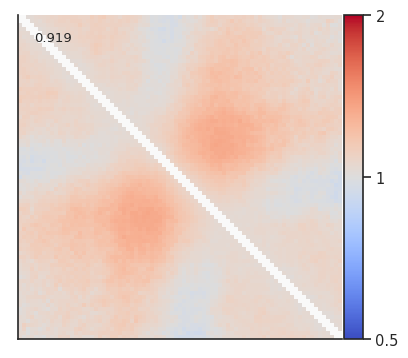

In [16]:
tad_sampled['chrom'] = tad_sampled['chr1']
tad_sampled['start']= tad_sampled['genomic_position']-100
tad_sampled['end']= tad_sampled['genomic_position']+100

for p in [2]:
    clr = phase_clrs[p]
    exp0 =  pd.read_csv(exps[p], sep='\t')

    pupc = coolpup.pileup(clr, tad_sampled[['chrom','start','end']], features_format='bed', local=True, view_df=hg38_arms,
                                    flank=200_000, expected_df = exp0, min_diag=0, nproc=8, subset=1000)
    fg = plotpup.plot(pupc,
                         score=True, cmap='coolwarm', scale='log', sym=True,
                         height=5, vmax=2)
    fg
    #fg.savefig("sampled_tad_pileup.svg") 

Text(0, 0.5, 'Count')

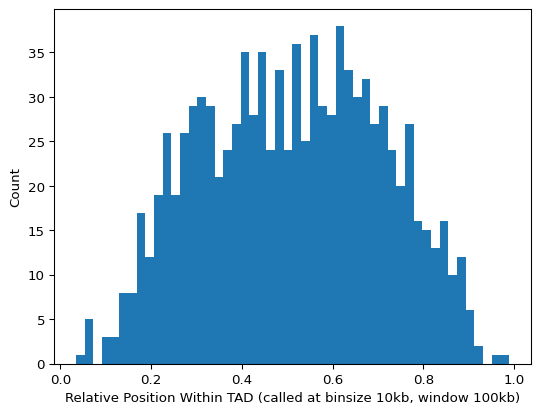

In [15]:
plt.hist(out, bins=50)
plt.xlabel('Relative Position Within TAD (called at binsize 10kb, window 100kb)')
plt.ylabel('Count')
#plt.savefig(os.path.join(savedir, "mm_positions_within_tad.svg"))

Text(0, 0.5, 'Count')

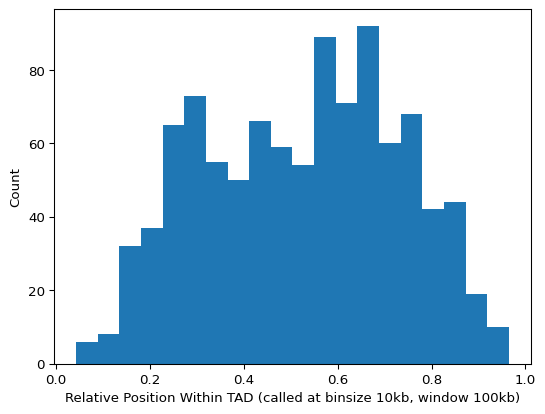

In [15]:
plt.hist(tad_sampled['tad_position'], bins=20)
plt.xlabel('Relative Position Within TAD (called at binsize 10kb, window 100kb)')
plt.ylabel('Count')

In [12]:
# write the sampled TAD positions to be used in example figure 
tad_sampled.to_csv('/mnt/md0/varshini/Analysis/Blood/complete_analyses/matchmakers/tads_position_sampled_10kb_100kbw.bed',
                  sep="\t")

INFO:coolpuppy:('chr4_p', 'chr4_p'): 4
INFO:coolpuppy:('chr7_p', 'chr7_p'): 1
INFO:coolpuppy:('chr6_p', 'chr6_p'): 3
INFO:coolpuppy:('chr9_p', 'chr9_p'): 2
INFO:coolpuppy:('chr3_p', 'chr3_p'): 2
INFO:coolpuppy:('chr2_p', 'chr2_p'): 3
INFO:coolpuppy:('chr8_q', 'chr8_q'): 2
INFO:coolpuppy:('chr10_p', 'chr10_p'): 1
INFO:coolpuppy:('chr5_q', 'chr5_q'): 3
INFO:coolpuppy:('chr1_p', 'chr1_p'): 6
INFO:coolpuppy:('chr9_q', 'chr9_q'): 3
INFO:coolpuppy:('chr6_q', 'chr6_q'): 7
INFO:coolpuppy:('chr11_p', 'chr11_p'): 1
INFO:coolpuppy:('chr4_q', 'chr4_q'): 1
INFO:coolpuppy:('chr3_q', 'chr3_q'): 1
INFO:coolpuppy:('chr10_q', 'chr10_q'): 2
INFO:coolpuppy:('chr16_p', 'chr16_p'): 1
INFO:coolpuppy:('chr17_p', 'chr17_p'): 1
INFO:coolpuppy:('chr12_q', 'chr12_q'): 2
INFO:coolpuppy:('chr15_q', 'chr15_q'): 3
INFO:coolpuppy:('chr14_q', 'chr14_q'): 3
INFO:coolpuppy:('chr11_q', 'chr11_q'): 3
INFO:coolpuppy:('chr19_p', 'chr19_p'): 1
INFO:coolpuppy:('chr21_q', 'chr21_q'): 1
INFO:coolpuppy:('chr20_q', 'chr20_q'): 2
I

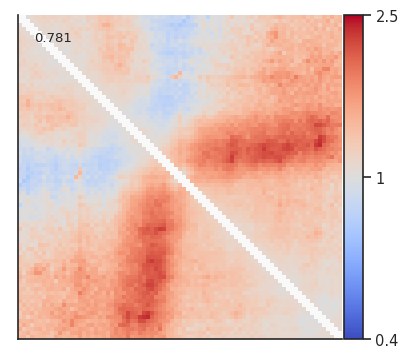

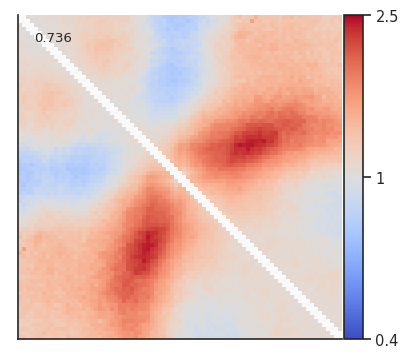

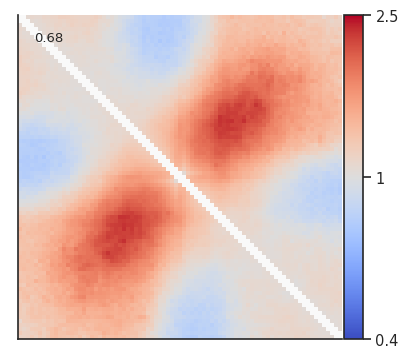

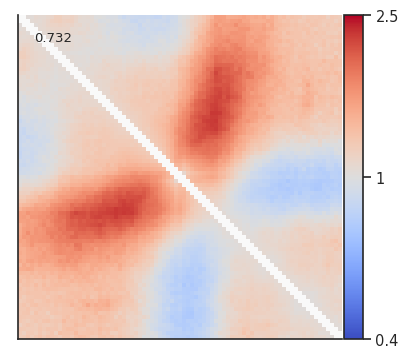

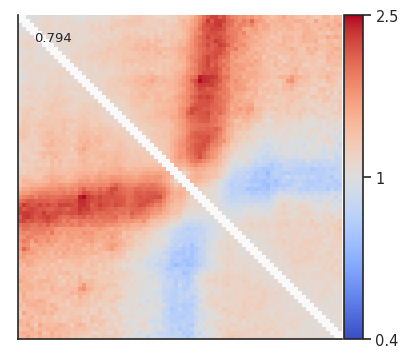

In [44]:
counts2, bin_edges2 = np.histogram(pd.Series(out).dropna(), bins=5, density=False)
bin_edges2 = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
for i, binn in enumerate(bin_edges2):
    if i > 0:
        track_sub_sub = track_sub[(track_sub['tad_position']>bin_edges2[i-1]) &  (track_sub['tad_position']<bin_edges2[i])]
        clr = phase_clrs[2]
        exp0 =  pd.read_csv(exps[2], sep='\t')

        pupc = coolpup.pileup(clr, track_sub_sub[['chrom','start','end']], features_format='bed', local=True, view_df=hg38_arms,
                                        flank=200_000, expected_df = exp0, min_diag=0, nproc=8)
        fg = plotpup.plot(pupc,
                             score=True, cmap='coolwarm', scale='log', sym=True,
                             height=5, vmax=2.5)
        fg.savefig(os.path.join(savedir, f"mm_pileup_bin_{binn}.svg"))
                          